GA7: 509 members, dT mean=4.636 K
GA8: 503 members, dT mean=4.751 K
GA9: 503 members, dT mean=4.743 K

Total pooled members: 1515


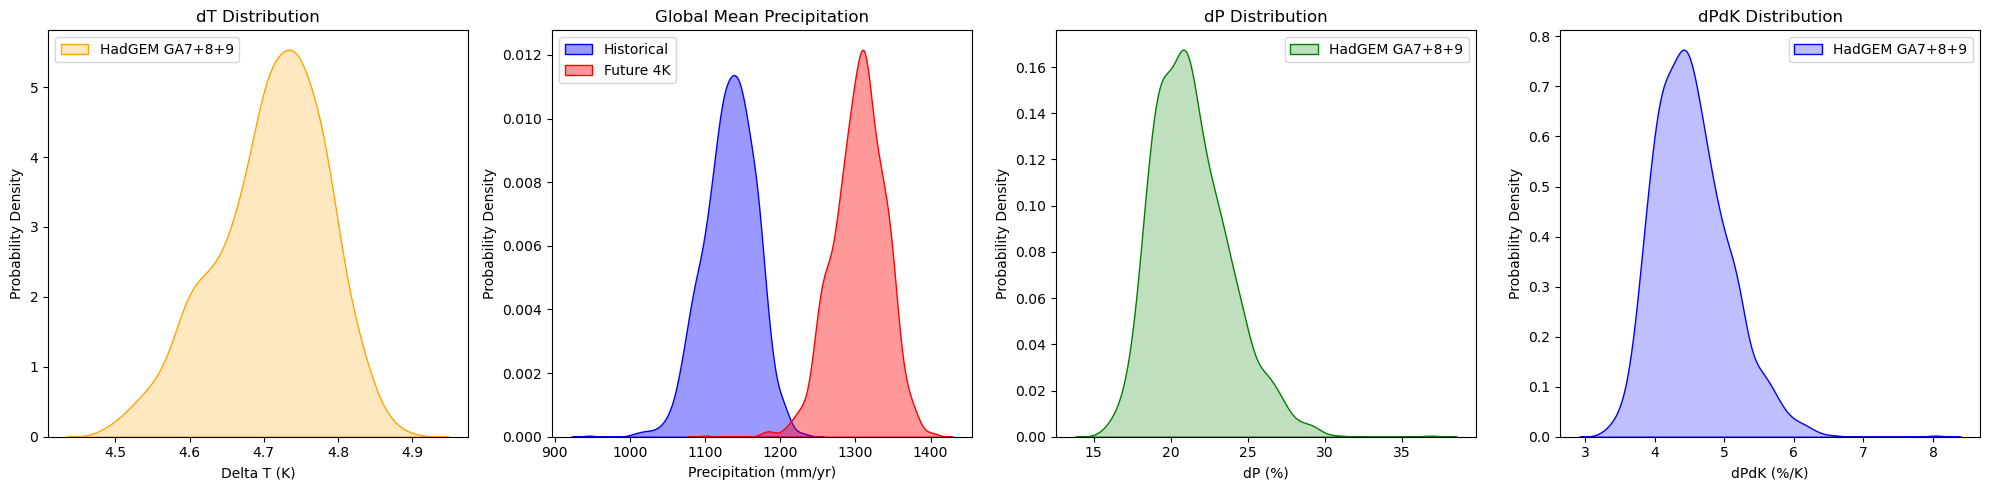

In [1]:
"""Compare dT, dP, and dPdK distributions across HadGEM GA7, GA8, GA9 PPEs"""

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

base_dir = "/Users/ewellmeyer/Documents/research/HadGEM/"

# Define configs: GA7 uses ts (surface_temperature), GA8/GA9 use tas (air_temperature)
configs = {
    'GA7': {'pr_var': 'precipitation_flux', 'ts_var': 'surface_temperature',
            'ts_prefix': 'ts'},
    'GA8': {'pr_var': 'precipitation_flux', 'ts_var': 'air_temperature',
            'ts_prefix': 'tas'},
    'GA9': {'pr_var': 'precipitation_flux', 'ts_var': 'air_temperature',
            'ts_prefix': 'tas'},
}

all_delta_T = []
all_dP_pct = []
all_dPdK = []
all_pr_his_gm = []
all_pr_fut_gm = []

for ga, cfg in configs.items():
    pr_his_ds = xr.open_dataset(os.path.join(base_dir, f"{ga}_pr_his_clim.nc"))
    pr_fut_ds = xr.open_dataset(os.path.join(base_dir, f"{ga}_pr_fut_clim.nc"))
    ts_his_ds = xr.open_dataset(os.path.join(base_dir, f"{ga}_{cfg['ts_prefix']}_his_clim.nc"))
    ts_fut_ds = xr.open_dataset(os.path.join(base_dir, f"{ga}_{cfg['ts_prefix']}_fut_clim.nc"))

    # convert to mm/yr
    pr_his = pr_his_ds[cfg['pr_var']] * 86400 * 365.25
    pr_fut = pr_fut_ds[cfg['pr_var']] * 86400 * 365.25

    # cos(lat) weights
    weights = np.cos(np.deg2rad(ts_his_ds['latitude']))
    weights.name = "weights"

    # global-mean precip for his and fut
    pr_his_gm = pr_his.weighted(weights).mean(dim=['latitude', 'longitude'])
    pr_fut_gm = pr_fut.weighted(weights).mean(dim=['latitude', 'longitude'])

    ts_his_gm = ts_his_ds[cfg['ts_var']].weighted(weights).mean(dim=['latitude', 'longitude'])
    ts_fut_gm = ts_fut_ds[cfg['ts_var']].weighted(weights).mean(dim=['latitude', 'longitude'])

    delta_T = ts_fut_gm - ts_his_gm
    delta_P = pr_fut - pr_his

    # global-mean percent change in precip (not yet normalized by dT)
    dP_pct = (delta_P / pr_his).weighted(weights).mean(dim=['latitude', 'longitude'])

    # global-mean percent change per K
    dPdK = ((delta_P / pr_his) / delta_T).weighted(weights).mean(dim=['latitude', 'longitude'])

    all_delta_T.append(delta_T.values)
    all_dP_pct.append(dP_pct.values * 100)
    all_dPdK.append(dPdK.values * 100)
    all_pr_his_gm.append(pr_his_gm.values)
    all_pr_fut_gm.append(pr_fut_gm.values)

    print(f"{ga}: {len(delta_T)} members, dT mean={float(delta_T.mean()):.3f} K")

# Pool across GA versions
all_delta_T = np.concatenate(all_delta_T)
all_dP_pct = np.concatenate(all_dP_pct)
all_dPdK = np.concatenate(all_dPdK)
all_pr_his_gm = np.concatenate(all_pr_his_gm)
all_pr_fut_gm = np.concatenate(all_pr_fut_gm)

print(f"\nTotal pooled members: {len(all_delta_T)}")

# --- Plot ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
sns.kdeplot(all_delta_T, color='orange', label='HadGEM GA7+8+9', fill=True, ax=ax)
ax.set_title('dT Distribution')
ax.set_xlabel('Delta T (K)')
ax.set_ylabel('Probability Density')
ax.legend()

ax = axes[1]
sns.kdeplot(all_pr_his_gm, color='blue', label='Historical', fill=True, alpha=0.4, ax=ax)
sns.kdeplot(all_pr_fut_gm, color='red', label='Future 4K', fill=True, alpha=0.4, ax=ax)
ax.set_title('Global Mean Precipitation')
ax.set_xlabel('Precipitation (mm/yr)')
ax.set_ylabel('Probability Density')
ax.legend()

ax = axes[2]
sns.kdeplot(all_dP_pct, color='green', label='HadGEM GA7+8+9', fill=True, ax=ax)
ax.set_title('dP Distribution')
ax.set_xlabel('dP (%)')
ax.set_ylabel('Probability Density')
ax.legend()

ax = axes[3]
sns.kdeplot(all_dPdK, color='blue', label='HadGEM GA7+8+9', fill=True, ax=ax)
ax.set_title('dPdK Distribution')
ax.set_xlabel('dPdK (%/K)')
ax.set_ylabel('Probability Density')
ax.legend()

plt.tight_layout()
plt.show()